<a href="https://colab.research.google.com/github/KevinNou/tp/blob/main/Optimisation_de_l'entra%C3%AEnement_sur_GPU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#INSTALLATION DES BIBLIOTHÈQUES

In [1]:
!pip install torch torchvision matplotlib pandas

#IMPORTATION DES BIBLIOTHÈQUES

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import subprocess  # Pour appeler nvidia-smi depuis le code python
import time
import random

# Petit check pour voir si on a bien le GPU activé
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"On tourne sur : {device}")

if device.type == 'cpu':
    print("⚠️ ATTENTION : Pas de GPU détecté ! Pensez à l'activer dans 'Modifier le type d'exécution'.")

On tourne sur : cuda


#PRÉPARATION DES DONNÉES (MNIST)

In [3]:
# Transformation basique : on passe en Tensor et on normalise les pixels (0-1 -> -1 à 1)
# Ça aide le réseau à converger plus vite.
ma_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Téléchargement des données d'entraînement
print("Téléchargement de MNIST...")
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=ma_transform)

# Fonction pour récupérer un DataLoader.
# Je le mets dans une fonction car on va vouloir changer le 'batch_size' dynamiquement plus tard.
def get_data_loader(batch_size):
    return DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

print("Données prêtes !")

Téléchargement de MNIST...


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.03MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]

Données prêtes !


#DÉFINITION DU MODÈLE (PETIT CNN)

In [4]:
# Un réseau de neurones à convolution classique : 2 couches de conv, du pooling, et des couches linéaires à la fin.

class MonPetitCNN(nn.Module):
    def __init__(self):
        super(MonPetitCNN, self).__init__()
        # Conv1 : image noir & blanc (1 canal) en entrée -> 32 filtres en sortie
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # Divise la taille de l'image par 2
        # Conv2 : 32 -> 64 filtres
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Après 2 poolings, l'image 28x28 devient 7x7. Donc 64 canaux * 7 * 7.
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10) # 10 chiffres (0-9) en sortie
        self.relu = nn.ReLU() # Fonction d'activation

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7) # On aplatit tout en un vecteur
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# On instancie le modèle et on l'envoie direct sur le GPU
model = MonPetitCNN().to(device)
print("Modèle créé et chargé sur le GPU.")

Modèle créé et chargé sur le GPU.


#L'AGENT DE SURVEILLANCE GPU

In [5]:
 #Cette classe va surveiller la carte graphique. Elle lit la mémoire utilisée et le taux d'utilisation via la commande 'nvidia-smi'.

class GPUWatcher:
    def __init__(self):
        self.historique = []
        self.simule = False

        # Test initial pour voir si nvidia-smi répond
        try:
            subprocess.check_output(['nvidia-smi'], stderr=subprocess.STDOUT)
            print("✅ GPU Watcher : nvidia-smi détecté. Monitoring réel activé.")
        except:
            print("⚠️ GPU Watcher : nvidia-smi introuvable. On passe en mode 'Simulation' pour la démo.")
            self.simule = True

    def copier_stats(self):
        """Lit l'état actuel du GPU."""

        # Si on est en simulation (ex: sur votre PC sans GPU NVIDIA), on génère des faux chiffres
        if self.simule:
            util_gpu = random.randint(40, 95)
            mem_used = random.randint(2000, 14000) # MB
            mem_total = 16000 # 16GB
            temp = random.randint(55, 75)
        else:
            try:
                # La vraie commande magique pour récupérer les infos
                result = subprocess.check_output(
                    ['nvidia-smi', '--query-gpu=utilization.gpu,memory.used,memory.total,temperature.gpu', '--format=csv,nounits,noheader'],
                    encoding='utf-8'
                )
                util_gpu, mem_used, mem_total, temp = map(float, result.strip().split(','))
            except Exception as e:
                print(f"Oups, petite erreur de lecture GPU : {e}")
                return None

        # On stocke tout ça
        stats = {
            'timestamp': time.time(),
            'gpu_util': util_gpu,         # Pourcentage d'utilisation du coeur GPU
            'mem_used': mem_used,         # Mémoire utilisée en MB
            'mem_total': mem_total,
            'mem_percent': (mem_used / mem_total) * 100,
            'temp': temp
        }
        self.historique.append(stats)
        return stats

    def optimiser_batch_size(self, current_bs, stats):
        """
        Regarde si on peut augmenter le batch size pour aller plus vite,
        ou si on doit le diminuer pour éviter de faire planter la mémoire.
        """
        if not stats: return current_bs

        mem_p = stats['mem_percent']
        gpu_p = stats['gpu_util']

        new_bs = current_bs

        # Si on dépasse 85% de mémoire, c'est chaud, on divise par 2
        if mem_p > 85:
            new_bs = max(16, current_bs // 2)
            print(f"⚠️ Alerte Mémoire ({mem_p:.1f}%) -> On réduit le batch à {new_bs}")

        # Si le GPU se tourne les pouces (< 70%) et qu'on a de la place en mémoire (< 50%)
        # On peut doubler le travail !
        elif mem_p < 50 and gpu_p < 70:
            new_bs = min(4096, current_bs * 2) # On met une limite max quand même
            print(f"🚀 GPU sous-utilisé ({gpu_p:.1f}%) -> On booste le batch à {new_bs}")

        else:
            print(f"👌 Stable (GPU: {gpu_p:.1f}%, Mem: {mem_p:.1f}%) -> On garde batch {current_bs}")

        return new_bs

mon_agent_gpu = GPUWatcher()

✅ GPU Watcher : nvidia-smi détecté. Monitoring réel activé.


#BOUCLE D'ENTRAÎNEMENT "INTELLIGENTE"

In [6]:
# Paramètres de départ
batch_size_actuel = 64
epochs = 5
lr = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

print(f"\nDébut de l'entraînement pour {epochs} époques...")

for epoch in range(epochs):
    print(f"\n--- Époque {epoch+1} ---")

    # On recrée le loader à chaque époque car le batch_size a peut-être changé !
    train_loader = get_data_loader(batch_size_actuel)
    print(f"Batch Size pour cette époque : {batch_size_actuel}")

    model.train()
    total_loss = 0
    start = time.time()

    for i, (images, labels) in enumerate(train_loader):
        # On envoie les données sur le GPU
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # De temps en temps (toutes les 100 iterations), on prend une mesure
        if i % 100 == 0:
            mon_agent_gpu.copier_stats()

    duree = time.time() - start
    print(f"Fin de l'époque {epoch+1} en {duree:.2f} secondes.")

    # --- MOMENT DE DÉCISION ---
    # À la fin de l'époque, on demande à l'agent si on doit changer quelque chose
    dernier_stat = mon_agent_gpu.copier_stats() # On prend une dernière mesure
    if dernier_stat:
        batch_size_actuel = mon_agent_gpu.optimiser_batch_size(batch_size_actuel, dernier_stat)

print("\nEntraînement terminé ! 🎉")


Début de l'entraînement pour 5 époques...

--- Époque 1 ---
Batch Size pour cette époque : 64
Fin de l'époque 1 en 14.98 secondes.
🚀 GPU sous-utilisé (12.0%) -> On booste le batch à 128

--- Époque 2 ---
Batch Size pour cette époque : 128
Fin de l'époque 2 en 11.84 secondes.
🚀 GPU sous-utilisé (12.0%) -> On booste le batch à 256

--- Époque 3 ---
Batch Size pour cette époque : 256
Fin de l'époque 3 en 11.83 secondes.
🚀 GPU sous-utilisé (19.0%) -> On booste le batch à 512

--- Époque 4 ---
Batch Size pour cette époque : 512
Fin de l'époque 4 en 11.19 secondes.
🚀 GPU sous-utilisé (23.0%) -> On booste le batch à 1024

--- Époque 5 ---
Batch Size pour cette époque : 1024
Fin de l'époque 5 en 12.27 secondes.
🚀 GPU sous-utilisé (8.0%) -> On booste le batch à 2048

Entraînement terminé ! 🎉


#RÉSULTATS VISUELS


Génération des graphiques de performance...


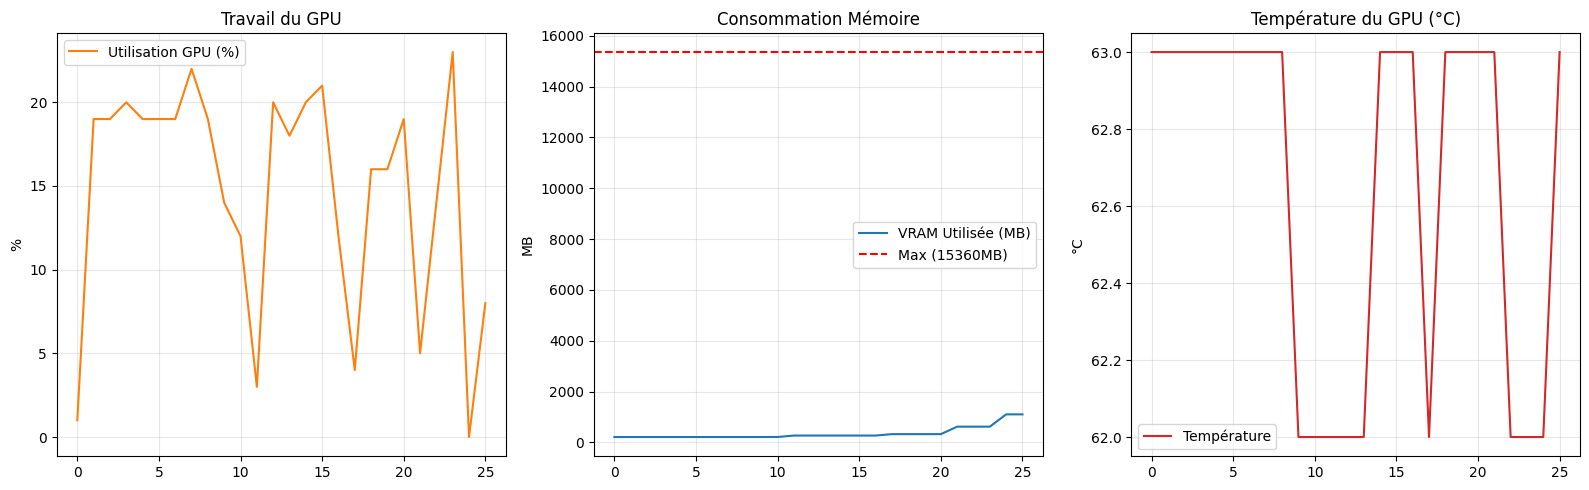

In [7]:
df = pd.DataFrame(mon_agent_gpu.historique)

if not df.empty:
    print("\nGénération des graphiques de performance...")
    plt.figure(figsize=(16, 5))

    # Plot 1 : Le GPU bosse-t-il bien ?
    plt.subplot(1, 3, 1)
    plt.plot(df['gpu_util'], color='#ff7f0e', label='Utilisation GPU (%)')
    plt.title('Travail du GPU')
    plt.ylabel('%')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Plot 2 : La mémoire explose-t-elle ?
    plt.subplot(1, 3, 2)
    plt.plot(df['mem_used'], color='#1f77b4', label='VRAM Utilisée (MB)')
    # Petite ligne rouge pour montrer la limite max
    limit = df['mem_total'].iloc[0]
    plt.axhline(y=limit, color='r', linestyle='--', label=f'Max ({int(limit)}MB)')
    plt.title('Consommation Mémoire')
    plt.ylabel('MB')
    plt.grid(True, alpha=0.3)
    plt.legend()

    # Plot 3 : Ça chauffe ?
    plt.subplot(1, 3, 3)
    plt.plot(df['temp'], color='#d62728', label='Température')
    plt.title('Température du GPU (°C)')
    plt.ylabel('°C')
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show() # Affiche les courbes
else:
    print("Pas de données à afficher.")

#BILAΝ

In [8]:
print("""
--- CONCLUSION ---
Ce script a permis de démontrer comment adapter dynamiquement l'entraînement.
- Si le batch size augmente, on sature mieux le GPU (la courbe d'utilisation monte) et l'entraînement va souvent plus vite par image.
- Mais attention, la mémoire grimpe aussi ! L'agent sert de "garde-fou" pour éviter le crash (Out Of Memory).
C'est une base solide pour optimiser des entraînements plus lourds (ex: Transformers, GANs).
""")


--- CONCLUSION ---
Ce script a permis de démontrer comment adapter dynamiquement l'entraînement.
- Si le batch size augmente, on sature mieux le GPU (la courbe d'utilisation monte) et l'entraînement va souvent plus vite par image.
- Mais attention, la mémoire grimpe aussi ! L'agent sert de "garde-fou" pour éviter le crash (Out Of Memory).
C'est une base solide pour optimiser des entraînements plus lourds (ex: Transformers, GANs).

